In [1]:
import numpy as np
import jax.numpy as jnp
import diffrax
import jax
from jax import grad, jacrev
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.integrate import solve_ivp
from scipy.integrate import ode
from time import time

jax.config.update("jax_enable_x64", True)
plt.rcParams.update({'font.size':10})



In [2]:
m = open('prion_model_ODE.net','r')
mLines = m.readlines()

for i in range(len(mLines)):
    
    if ('begin' in mLines[i])&('parameters' in mLines[i]):
        parInit = i+1
        
    if ('end' in mLines[i])&('parameters' in mLines[i]):
        parEnd = i
    
    if ('begin' in mLines[i])&('reactions' in mLines[i]):
        reactInit = i+1
        
    if ('end' in mLines[i])&('reactions' in mLines[i]):
        reactEnd = i
        
    if ('begin' in mLines[i])&('species' in mLines[i]):
        speciesInit = i+1
        
    if ('end' in mLines[i])&('species' in mLines[i]):
        speciesEnd = i    
    
parLines = mLines[parInit:parEnd]
lines = mLines[reactInit:reactEnd]  
speciesLines = mLines[speciesInit:speciesEnd]  
numPars = len(parLines)

In [3]:
# parameter block

par=[]
parListString=''

for parID in range(len(parLines)):
    
    parLines[parID]=parLines[parID].replace("^","**")
    
    separated= parLines[parID].split(' ')
    
    for index in range(len(separated)-1,-1,-1):
        
        if len(separated[index])==0:
            del separated[index]
    
    parListString += separated[1]+', '
    
    print(f'Parameter {parID} named {separated[1]} := {separated[2]}')
    exec(separated[1]+'='+separated[2])


packing = 'par=['+parListString+']'
unpacking = parListString+'=par'

exec(packing)

Parameter 0 named lambda_scaling_factor := 1.0
Parameter 1 named NA := 6.02214e23
Parameter 2 named Volume := 1e-12
Parameter 3 named a := 0.047
Parameter 4 named beta := 2.92e-3/lambda_scaling_factor
Parameter 5 named b := 0.0314
Parameter 6 named lambda_model_parameter := 30000*lambda_scaling_factor
Parameter 7 named d := 4
Parameter 8 named x_0 := lambda_model_parameter/d
Parameter 9 named n := 2
Parameter 10 named gamma := 100
Parameter 11 named epsilon := 1e-10
Parameter 12 named _InitialConc1 := 3*lambda_scaling_factor


In [4]:
numSpecies = len(speciesLines)
IC= jnp.zeros((numSpecies,))

for speciesID in range(numSpecies):
    
    separated= speciesLines[speciesID].split(' ')
    
    for index in range(len(separated)-1,-1,-1):
        
        if len(separated[index])==0:
            del separated[index]

    exec('IC=IC.at[speciesID].set('+separated[2]+')')

In [5]:
reactants = np.zeros((len(lines),10))
products = np.zeros((len(lines),10))
rates = jnp.zeros((len(lines), ))

for reactionID in range(len(lines)):
    
    separated= lines[reactionID].split(' ')
    
    for index in range(len(separated)-1,-1,-1):
        
        if len(separated[index])==0:
            del separated[index]
            
    reactantSet = separated[1].split(',')
    reactants[reactionID][0]=len(reactantSet)
    
    for reactantID in range(len(reactantSet)):
        reactants[reactionID][reactantID+1] = int(reactantSet[reactantID])-1
        
    productSet = separated[2].split(',')
    products[reactionID][0]=len(productSet)
    
    for productID in range(len(productSet)):
        products[reactionID][productID+1] = int(productSet[productID])-1

    exec( 'rates=rates.at[reactionID].set('+separated[3]+')')


In [6]:
# dimeriztion needs extra care

numReactions = len(rates)

minNum = 20
dimerizationIndex = np.zeros((numReactions,))

for i in range(len(rates)):

    if minNum > reactants[i][0]:
        
        minNum = reactants[i][0]
    
    if (reactants[i][0]==2)&(reactants[i][1]==reactants[i][2]):
        print('reaction ID='+str(i)+' is dimerization!!')
        print(asarray(reactants[i])+1)
        print(asarray(products[i])+1)
        
        dimerizationIndex[i]=1.

reactants=reactants.astype('int')
products=products.astype('int')
        

In [7]:
rates

Array([3.00e+04, 4.00e+00, 4.70e-02, ..., 6.28e-02, 3.14e-02, 6.28e-02],      dtype=float64)

In [8]:
@jax.jit
def RHS(t,X,rates):

    dx = jnp.zeros((numSpecies,))
    
    for i in range(numReactions):
        
        flux = rates[i]
        
        for j in range(1, reactants[i][0]+1):
            
            flux = flux*X[reactants[i][j]]
        
        for j in range(1, reactants[i][0]+1):

            dx = dx.at[ reactants[i][j] ].add(-flux)
            
        for j in range(1, products[i][0]+1):

            dx = dx.at[ products[i][j] ].add(+flux)

    return dx

In [9]:
tSpan = np.linspace(0,300,30001)
tol=1e-6

@jax.jit
def xt(rates):
    terms = diffrax.ODETerm(RHS)
    solver = diffrax.Dopri8()
    t0 = tSpan[0]
    t1 = tSpan[-1]
    dt0 = None
    saveat = diffrax.SaveAt(ts=tSpan)
    stepsize_controller = diffrax.PIDController(rtol=tol, atol=tol)       
    sol = diffrax.diffeqsolve(terms,solver,t0,t1,dt0,IC,args=(rates),saveat=saveat,stepsize_controller=stepsize_controller,max_steps=int(1e12))
    return sol.ys    

In [10]:
tic = time()
ys = xt(rates).T
print(f'jitting = {time()-tic}')

jitting = 155.65494298934937


In [11]:
bng = np.genfromtxt('prion_model_ODE.cdat')
bng_t = bng[:,0]
bng_x = bng[:,1:].T

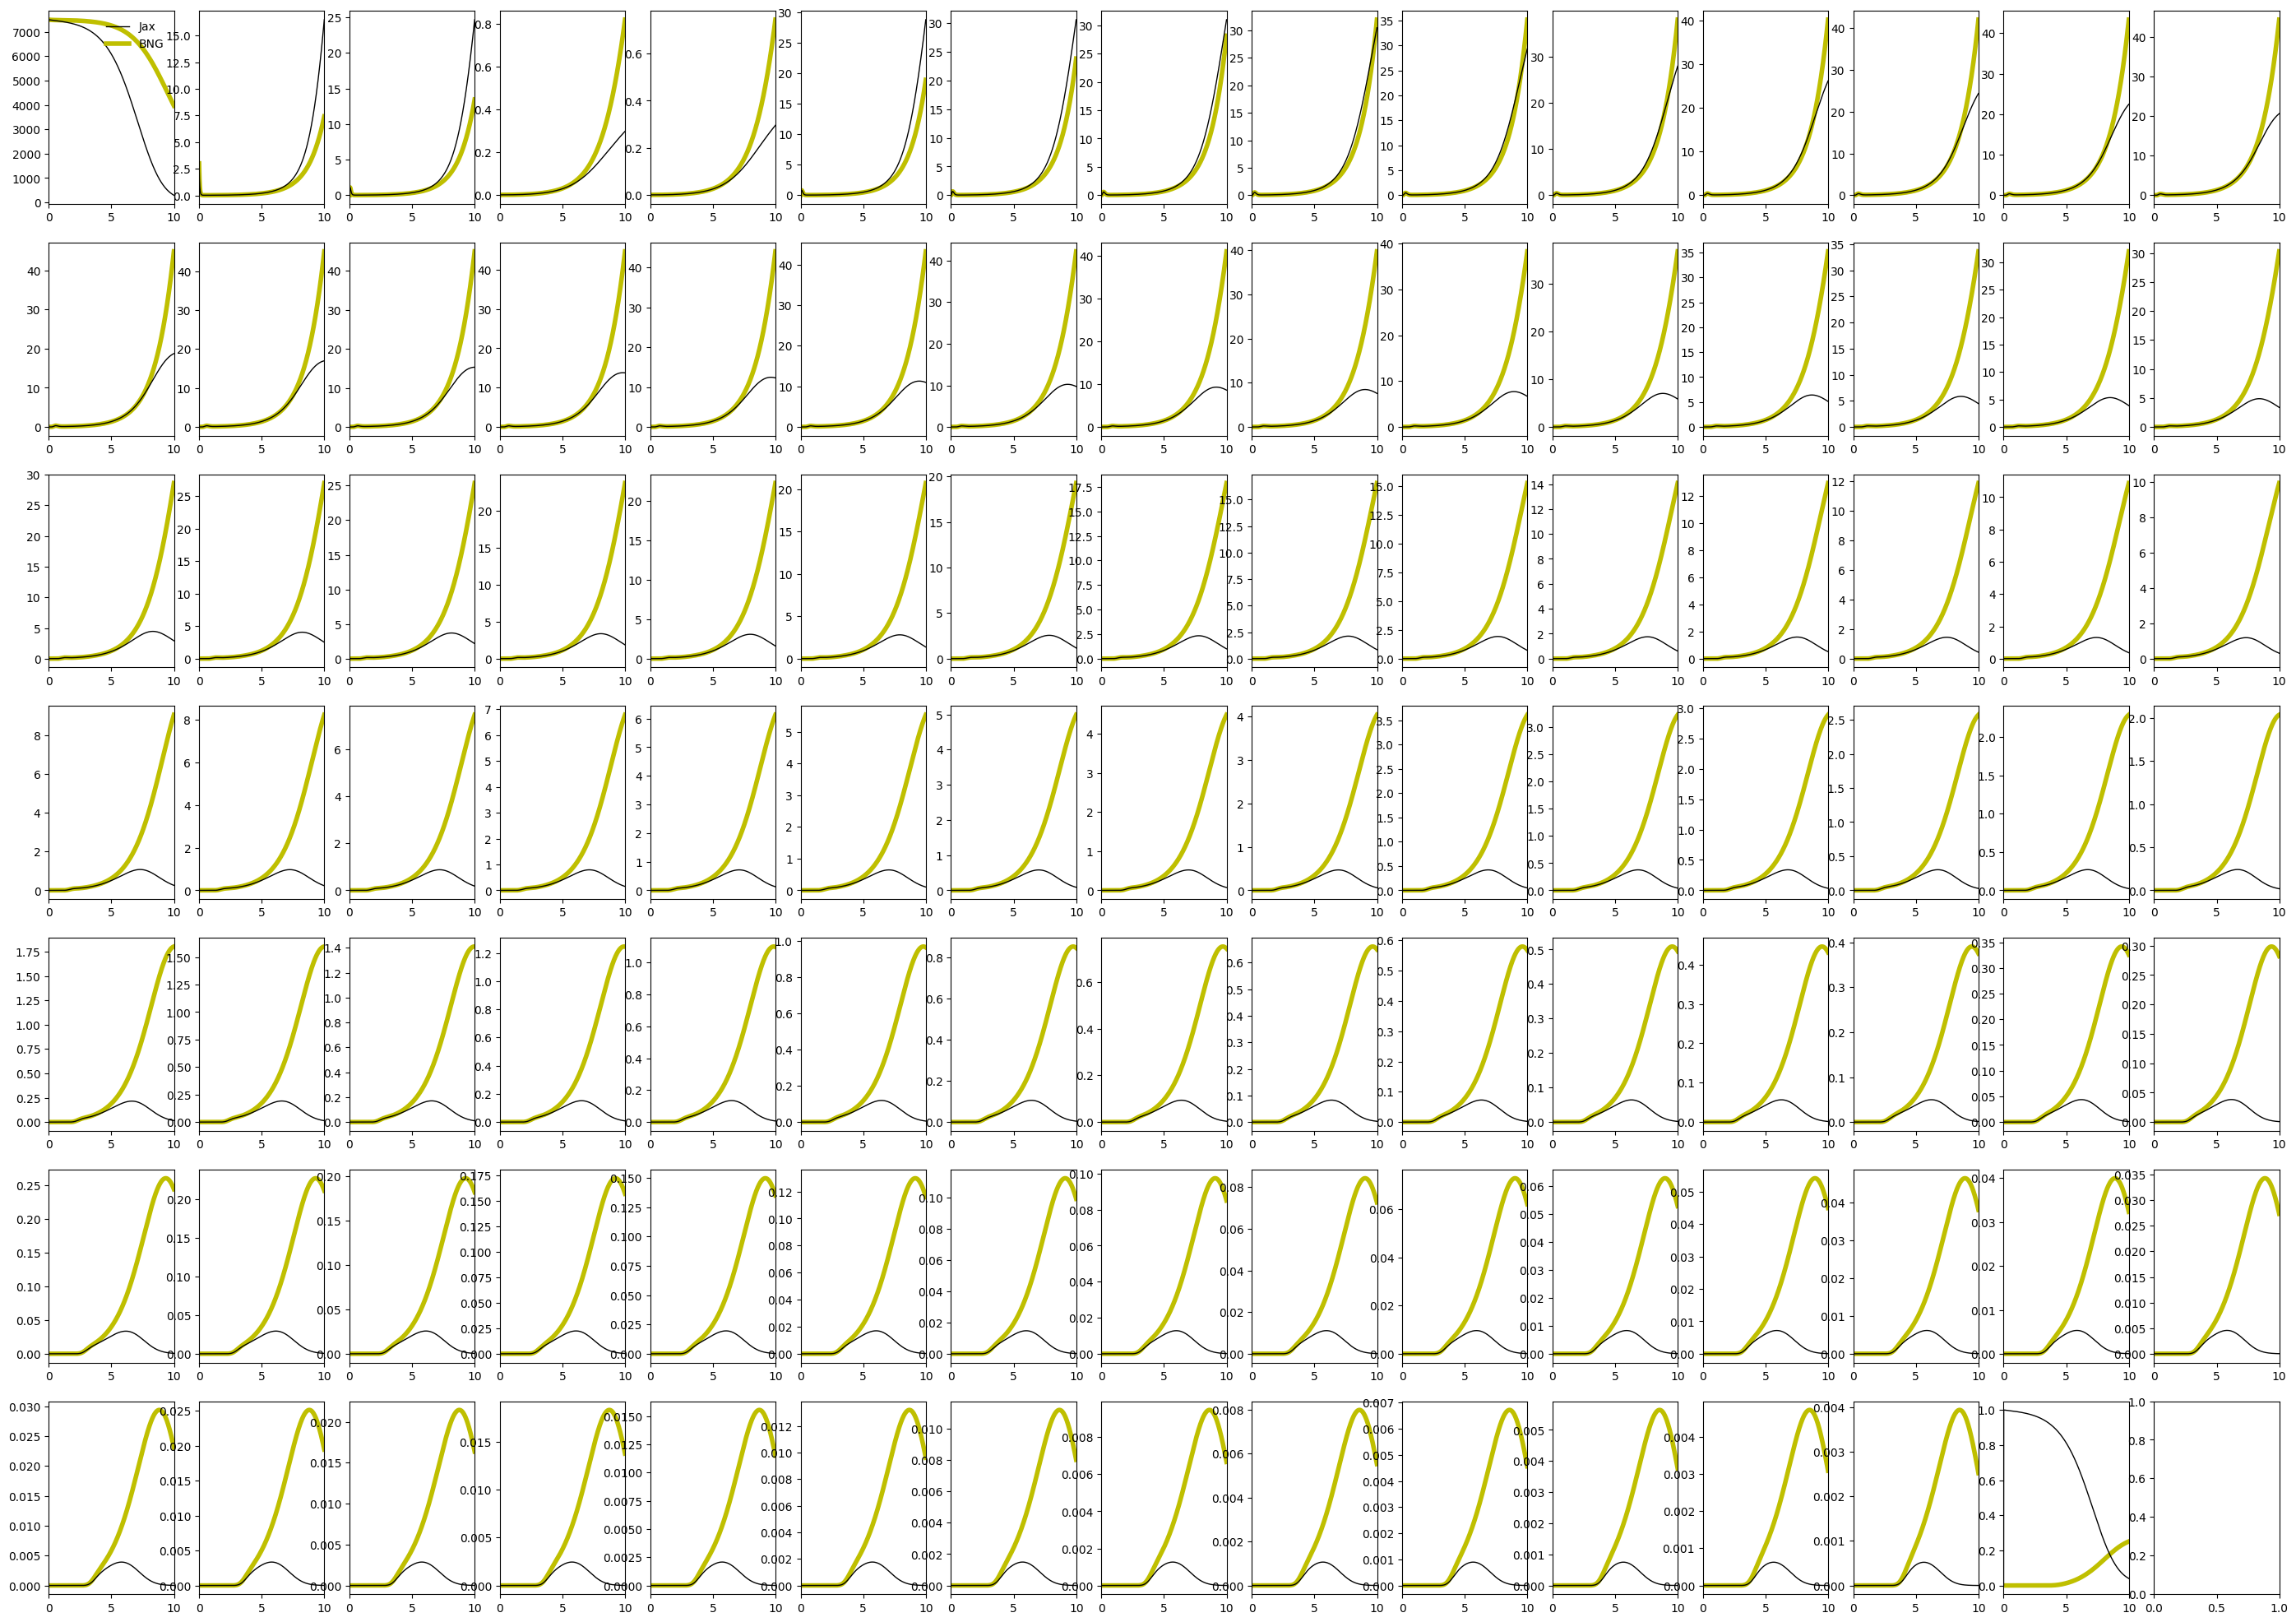

In [17]:
fig,ax = plt.subplots(7,15,figsize=(35,25))
t_end = 1000

for i in range(7):
    for j in range(15):
        index = i*15+j
        if index<104:
            ax[i][j].plot(tSpan[:t_end], ys[index,:t_end], zorder=2, lw=1, color='k', label='Jax')
            ax[i][j].plot(bng_t[:t_end], bng_x[index,:t_end],zorder=1, lw=4, color='y', label='BNG')
            ax[i][j].set_xlim(tSpan[[0,t_end]])
            if index==0:
                ax[i][j].legend(loc=1, frameon=False)                